In [4]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
import PhysicalConstants.CODATA2018: c_0
using Unitful

In [5]:
function mask_ellipse(xc, yc, a, b, θ, width, height)
    """ Mask of size (width, height) of an ellipse rotated by an angle θ, centered on [xc, yc], with HALF major/minor axis a/b"""
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end


function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        imgw = rot_img(img, θ)

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

function rot_img(img, θ)
    """ Rotate an image with an angle θ, padd with 0 """
    trfm = recenter(RotMatrix(θ), center(img))
    imgw = parent(warp(img, trfm))
    imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
    return imgw
end

function find_rotate_angle_stripes(img)
    """ Find the angle of the stripes and return the image rotated by this angle 
    so that the stripes are along the horizontal axis, and the angle as a 2nd argument """
    θ = rotate_img_stripe_angle(img)
    return rot_img(img, θ), θ
end

find_rotate_angle_stripes (generic function with 1 method)

In [6]:
# pathdir = "Y:/TwoDGas/2026/02/06/0000" # Stripes 60°
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds
@load "Saved_exp_data/Nbr_atoms_per_stripe_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Nbr_atoms_per_stripe;
nbr_amp_laser = length(unique(Amplitude_laser))

# Atomic data
Γ = 2.02e8 # In Hz
λ = 421e-9 # In m
ω0 = 2π*ustrip(c_0)/λ
Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2

# size_pxl = 0.187e-6
size_pxl = 0.1966e-6 # New pxl size since 2025/12/31

factor_ellipse = 2; # Half-axis ellipse =  major_axis_stripes_ds/factor_ellipse. For integrating over the fitted stripe, we should take factor_ellipse = 2.

### Check validity of droplet region

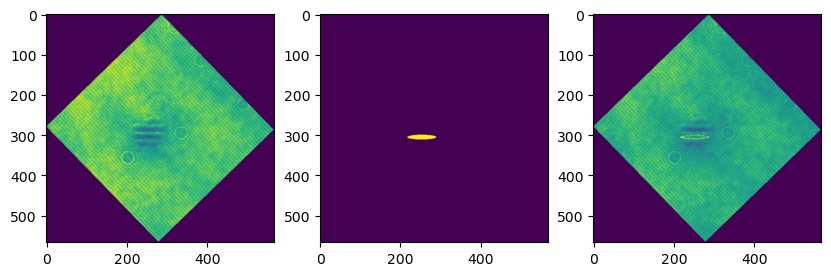

In [7]:
i, j, k = 19, 13, 1

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

img_rot = find_rotate_angle_stripes(Imgs_atoms_crop_ds[i, j, :, :])[1]

axs[1].imshow(img_rot)

if nbr_stripes_ds[i, j] > 0
    mask = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(img_rot)[1], size(img_rot)[2])
    axs[2].imshow(mask)
    axs[3].imshow(img_rot .+ mask.*img_rot)
end


# pygui(true); show()
pygui(false);

### Intensity integrated over the stripes

In [8]:
Iatoms_stripes, Ibkg_stripes, Idark_stripes = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

# Convertion factor to go from electrons to photons
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:size(Imgs_atoms_crop_ds)[1])
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        
        if nbr_stripes_ds[i, j] > 0
            img_atoms_rot, θ_img = find_rotate_angle_stripes(Imgs_atoms_crop_ds[i, j, :, :])
            img_bkg_rot = rot_img(Imgs_bkg_crop_ds[i, j, :, :], θ_img)
            img_dark_rot = rot_img(Imgs_dark_crop_ds[i, j, :, :], θ_img)
        end

        for k in 1:Int(nbr_stripes_ds[i, j]) # As the surface is different for each stripe, we have to add the intensity for each one of them
            
            S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
            if S_stripe > 0
                mask_stripe = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(img_atoms_rot)[1], size(img_atoms_rot)[2])

                # Add each stripe divided by it's surface and atom nbr
                Iatoms_stripes[i, j] += sum(mask_stripe .* img_atoms_rot) * Convertion_factor / (S_stripe * nbr_stripes_ds[i, j]) # * Nbr_atoms_per_stripe
                Ibkg_stripes[i, j] += sum(mask_stripe .* img_bkg_rot) * Convertion_factor / (S_stripe * nbr_stripes_ds[i, j])
                Idark_stripes[i, j] += sum(mask_stripe .* img_dark_rot) * Convertion_factor / (S_stripe * nbr_stripes_ds[i, j])
            end
        end
    end
end

0.0%┣                                              ┫ 0/19 [00:04<-1:-13, -4s/it]
10.5%┣█████                                          ┫ 2/19 [00:09<02:40, 9s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:14<01:55, 7s/it]
21.1%┣██████████                                     ┫ 4/19 [00:19<01:35, 6s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:23<01:21, 6s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:27<01:09, 5s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:31<01:01, 5s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:33<00:52, 5s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:39<00:49, 5s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:43<00:43, 5s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:47<00:38, 5s/it]
63.2%┣█████████████████████████████                 ┫ 12/19 [00:51<00:33, 5s/it]
68.4%┣██████████████████████

### Compute mean/std

In [9]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)

for i = 1:size(Imgs_atoms_crop_ds)[1]
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_stripes_ds[i, j] > 0
            push!(atoms, Iatoms_stripes[i, j]), push!(bkg, Ibkg_stripes[i, j]), push!(dark, Idark_stripes[i, j]), push!(bkg_atoms, Ibkg_stripes[i, j]-Iatoms_stripes[i, j])
        end
    end
    if length(atoms) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

### Save data

In [10]:
@save "Saved_exp_data/Intensity_integrated_stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Iatoms_stripes Ibkg_stripes Idark_stripes Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

In [11]:
# @load "Saved_exp_data/Intensity_integrated_stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Iatoms_stripes Ibkg_stripes Idark_stripes Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

### Plots w.r.t. calculated Sat

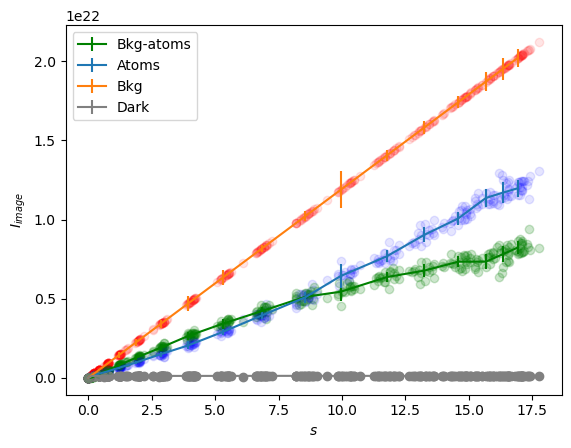

PyObject <matplotlib.legend.Legend object at 0x18d98d220>

In [12]:
errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")
errorbar(Mean_bkg/Isat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Mean_bkg/Isat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Mean_bkg/Isat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")

for i = 1:size(Iatoms_stripes)[1]
    for j = 1:size(Iatoms_stripes)[2]
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Iatoms_stripes[i, j], color="b", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j], color="r", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Idark_stripes[i, j], color="grey")
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

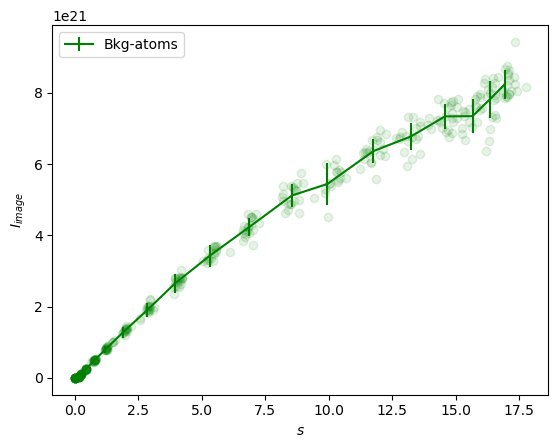

PyObject <matplotlib.legend.Legend object at 0x1a66c2840>

In [13]:
errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")  

for i = 1:size(Iatoms_stripes)[1]
    for j = 1:size(Iatoms_stripes)[2]
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


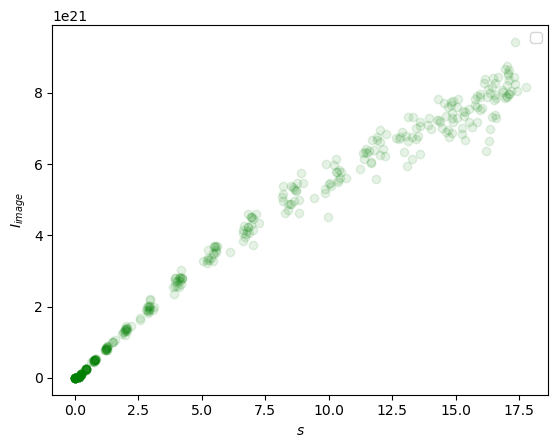

PyObject <matplotlib.legend.Legend object at 0x1a6dc2840>

In [14]:
# errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")  

for i = 1:size(Iatoms_stripes)[1]
    for j = 1:size(Iatoms_stripes)[2]
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

### Get the light emited by atoms normalised by atom nbr

In [15]:
I_bkg_atoms_stripes_per_atm = zeros(size(Imgs_atoms_crop_ds)[1:2])

# Convertion factor to go from electrons to photons
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:size(Imgs_atoms_crop_ds)[1])
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        
        if nbr_stripes_ds[i, j] > 0
            img_atoms_rot, θ_img = find_rotate_angle_stripes(Imgs_atoms_crop_ds[i, j, :, :])
            img_bkg_rot = rot_img(Imgs_bkg_crop_ds[i, j, :, :], θ_img)
            img_dark_rot = rot_img(Imgs_dark_crop_ds[i, j, :, :], θ_img)
        end

        for k in 1:Int(nbr_stripes_ds[i, j]) # As the surface is different for each stripe, we have to add the intensity for each one of them
            
            S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
            if S_stripe > 0
                mask_stripe = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(img_atoms_rot)[1], size(img_atoms_rot)[2])

                # Add each stripe divided by it's surface and atom nbr
                I_bkg_atoms_stripes_per_atm[i, j] += (sum(mask_stripe .* img_bkg_rot) * Convertion_factor / (S_stripe * nbr_stripes_ds[i, j])-sum(mask_stripe .* img_atoms_rot) * Convertion_factor / (S_stripe * nbr_stripes_ds[i, j])) / Nbr_atoms_per_stripe[i, j, k]
            end
        end
    end
end

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]
10.5%┣█████                                          ┫ 2/19 [00:04<01:04, 4s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:08<01:04, 4s/it]
21.1%┣██████████                                     ┫ 4/19 [00:12<00:58, 4s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:16<00:55, 4s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:18<00:48, 4s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:22<00:43, 4s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:24<00:38, 3s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:28<00:35, 3s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:31<00:31, 3s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:34<00:27, 3s/it]
63.2%┣█████████████████████████████                 ┫ 12/19 [00:38<00:24, 3s/it]
68.4%┣██████████████████████

In [16]:
Mean_bkg_atoms_stripes_per_atm = zeros(nbr_amp_laser)
Std_bkg_atoms_stripes_per_atm = zeros(nbr_amp_laser)

for i = 1:size(Imgs_atoms_crop_ds)[1]
    bkg_atoms_per_atm = []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_stripes_ds[i, j] > 0
            push!(bkg_atoms_per_atm, I_bkg_atoms_stripes_per_atm[i, j])
        end
    end
    if length(bkg_atoms_per_atm) > 0
        Mean_bkg_atoms_stripes_per_atm[i] = mean(bkg_atoms_per_atm)
        Std_bkg_atoms_stripes_per_atm[i] = std(bkg_atoms_per_atm)
    end
end

In [17]:
errorbar(Mean_bkg/Isat, Mean_bkg_atoms_stripes_per_atm, yerr=Std_bkg_atoms_stripes_per_atm, label="Bkg-atoms", color="green")  

# close("all")
# fig = subplot()

# for i = 1:size(Iatoms_stripes)[1]
#     for j = 1:size(Iatoms_stripes)[2]
#         scatter(Ibkg_stripes[i, j]/Isat, I_bkg_atoms_stripes_per_atm[i, j], color="g", alpha = 0.1)
#     end
# end

xlabel(L"s")
ylabel(L"I_{image}")

legend()
pygui(true); show()

sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
